<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/07-polynomial-regression-overfitting/%D0%9F%D0%BE%D0%BB%D0%B8%D0%BD%D0%BE%D0%BC%D0%B8%D0%B0%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F_%D0%B8_%D0%BF%D0%B5%D1%80%D0%B5%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Полиномиальная регрессия

**Цель работы:**

Изучить полиномиальную регрессию как расширение линейной модели

Научиться визуализировать результаты моделей

Исследовать влияние степени полинома на качество модели

Понять явление переобучения (overfitting)

В данной работе используется искусственно сгенерированный набор данных, отражающий зависимость потребления энергии от температуры окружающей среды. Предполагается, что при умеренной температуре (около 20°C) энергопотребление минимально, так как отсутствует необходимость в активном отоплении или охлаждении. При понижении температуры увеличивается использование отопительных систем, а при повышении — систем кондиционирования, что приводит к росту энергопотребления. Таким образом, зависимость носит нелинейный (приближённо параболический) характер. Дополнительно в данные добавлен случайный шум, имитирующий реальные колебания и погрешности измерений.

Шаг 1. Загрузите данные из файла.

ВАЖНО: предварительно перенесите файл в хранилище колаба (drag and drop).

In [ ]:
import pandas as pd

dataset = pd.read_csv('energy_data.csv')

Шаг 2. Разбейте данные на входные и выходные признаки (x, y)

In [ ]:
X = dataset[['Temperature']]
y = dataset['Energy_Consumption']

Шаг 3. Постройте визуализацию исходных данных, изучите данные

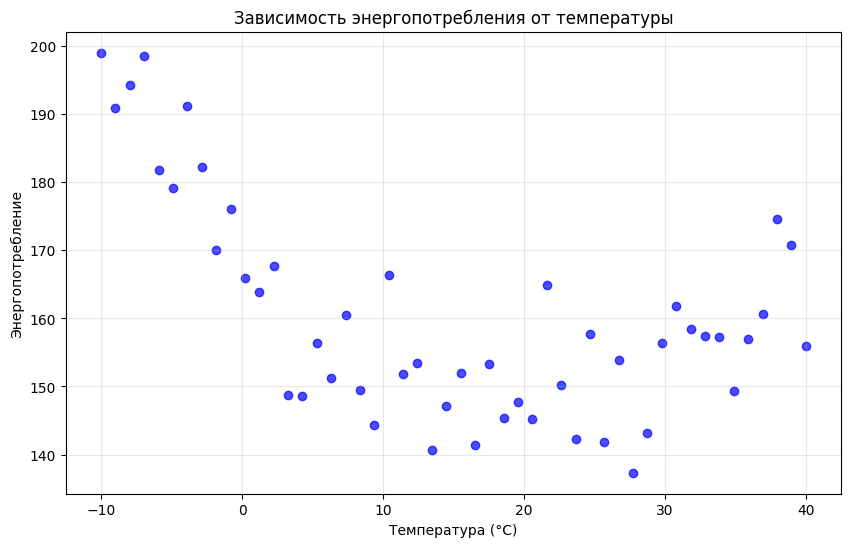

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7)
plt.xlabel('Температура (°C)')
plt.ylabel('Энергопотребление')
plt.title('Зависимость энергопотребления от температуры')
plt.grid(True, alpha=0.3)
plt.show()

Шаг 4. Обучите модель линейной регрессии, выведите коэффициент детерминации (R²), постройте график

R² для линейной регрессии: 0.3064


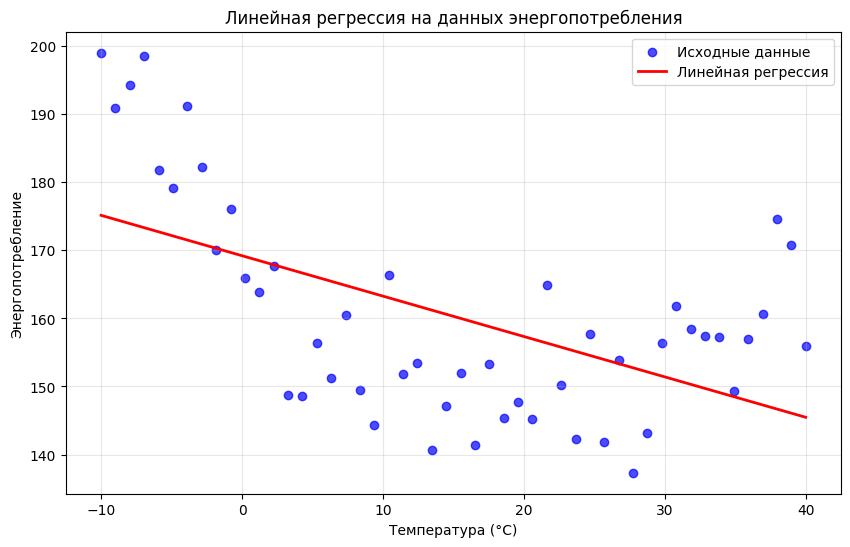

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred_linear = lin_reg.predict(X)

r2_linear = r2_score(y, y_pred_linear)
print(f"R² для линейной регрессии: {r2_linear:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Исходные данные')
plt.plot(X, y_pred_linear, color='red', linewidth=2, label='Линейная регрессия')
plt.xlabel('Температура (°C)')
plt.ylabel('Энергопотребление')
plt.title('Линейная регрессия на данных энергопотребления')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Вопрос: хорошо ли линейная регрессия описывает данные? Поясните почему.

Нет, линейная регрессия плохо описывает эти данные. Низкий R^2. Прямая линия не может уловить U-образную форму зависимости.

Шаг 5. Постройте полиномиальную модель степени 2, постройте график, вычислите R²

R² для полинома степени 2: 0.7947
Уравнение: y = -2.30·x + 0.06·x² + 169.64


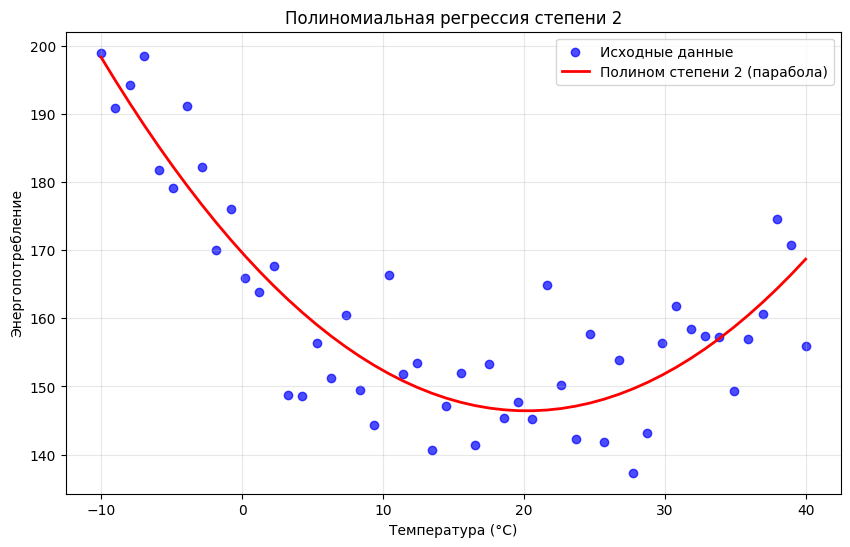

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2)

X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

y_pred_poly2 = poly_reg.predict(X_poly)

r2_poly2 = r2_score(y, y_pred_poly2)
print(f"R² для полинома степени 2: {r2_poly2:.4f}")

coefs = poly_reg.coef_
intercept = poly_reg.intercept_
print(f"Уравнение: y = {coefs[1]:.2f}·x + {coefs[2]:.2f}·x² + {intercept:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Исходные данные')
plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label='Полином степени 2 (парабола)')
plt.xlabel('Температура (°C)')
plt.ylabel('Энергопотребление')
plt.title('Полиномиальная регрессия степени 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Шаг 6. Повторите шаг 5 для степеней: 3,5,8. Для каждой модели:
обучите модель, вычислите R², постройте график

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


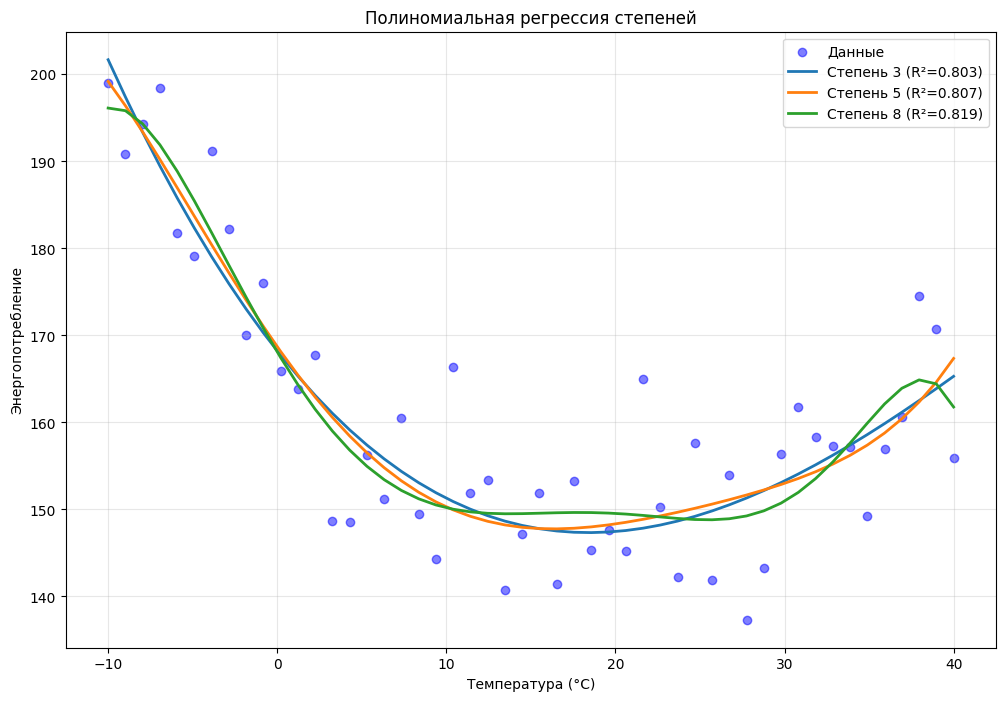

In [ ]:
dataset = pd.read_csv('energy_data.csv')
X = dataset[['Temperature']]
y = dataset['Energy_Consumption']

degrees = [3,5,8]

plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='blue', alpha=0.5, label='Данные')

for d in degrees:

    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)
    r2 = r2_score(y, y_pred)
    X_sorted = np.sort(X, axis=0)
    X_sorted_poly = poly.transform(X_sorted)
    y_sorted_pred = model.predict(X_sorted_poly)

    plt.plot(X_sorted, y_sorted_pred, linewidth=2, label=f'Степень {d} (R²={r2:.3f})')

plt.xlabel('Температура (°C)')
plt.ylabel('Энергопотребление')
plt.title(f'Полиномиальная регрессия степеней')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ответьте на вопросы:

Как изменяется форма графика при увеличении степени полинома? Становится более извилистой.

До какого момента качество модели (R²) улучшается? до 5-8 степени.

Начиная с какой степени модель начинает вести себя нестабильно? c 7+

Что происходит с графиком при высокой степени? Линия пытается пройти через каждую точку и сильно гнется

Что такое переобучение в данном примере? Линия акцентируется на каждой точке без закономерности